In [2]:
###### model validation
###### leave one-site out
###### loop all sites
###### created by Qing Ying (qying@umd.edu)


import os
import sys
import urllib.request
import re
import argparse
import math
import numpy as np
import pandas as pd
import netCDF4 as nc
import xarray as xr
import matplotlib.pyplot as plt
import datetime
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
import pickle
from scipy import stats

    
df = pd.read_csv('/explore/nobackup/people/spotter5/anna_v/v2/qing/flux_data.csv', index_col=0, parse_dates=True)

x_col = ['nbar1','nbar2','nbar3','nbar4','nbar5','nbar6','nbar7','sm_r_wetness','sm_s_wetness','sm_p_wetness','pa','tas','rsds','rsdl','le','h','spfh','ts1','ts2','ts3','dem','slope','spi','cti']
y_col = ['FCH4_mean']
dfs = df[['NewID','FCH4_count']+ y_col + x_col]
dfs = dfs.dropna()
dfs = dfs.loc[dfs['FCH4_count']>11]
dfs.info()

site_df = pd.read_csv('/explore/nobackup/people/spotter5/anna_v/v2/qing/site_list.csv')
filter_df = site_df.loc[(site_df['WETLAND_CL']=='Fen') | (site_df['WETLAND_CL']=='Bog') | (site_df['WETLAND_CL']=='Wet tundra')]
print(filter_df)

models_df = pd.DataFrame()
predicts_df = pd.DataFrame()

n = 0
for row in filter_df.itertuples(index=True, name='Pandas'):
    id = row.NewID
    # val df
    dfss = dfs.loc[dfs['NewID']==id]
    # train df
    dfm = dfs.loc[dfs['NewID']!=id]
    if dfss.empty:
        continue
    else:
        n=n+1
        x = dfm[x_col]
        y = dfm[y_col]
        regressor = RandomForestRegressor(n_estimators=100, oob_score=True,  max_samples=0.8, max_features="sqrt", max_depth=10, min_impurity_decrease=0.1, min_samples_split=10, min_samples_leaf=4)
        regressor = regressor.fit(x,y)
        y_pred = regressor.predict(x)
        dfm['FCH4_pre'] = y_pred
        xhat = dfss[x_col]
        yhat = dfss[y_col]
        yhat_pred = regressor.predict(xhat)
        dfss['FCH4_pre']= yhat_pred
        tree_preds = np.stack([t.predict(xhat) for t in regressor.estimators_], axis=1)
        pred_variance = np.var(tree_preds, axis=1)
        dfss['FCH4_err']=np.sqrt(pred_variance)
        predicts_df = predicts_df.append(dfss, ignore_index=False)
        # model test
        rmse = np.sqrt(metrics.mean_squared_error(y, y_pred))
        r2 = regressor.score(x,y)
        # model validation of independent site
        mean = dfss['FCH4_mean'].mean()
        sd = dfss['FCH4_mean'].std()       
        dfss = dfss.loc[dfss['FCH4_mean'] <= mean+(3*sd)]
        yhat = dfss['FCH4_mean']
        yhat_pred = dfss['FCH4_pre']
        valrmse = np.sqrt(metrics.mean_squared_error(yhat, yhat_pred))
        valmae = metrics.mean_absolute_error(yhat, yhat_pred)
        slope, intercept, r_value, p_value, se = stats.linregress(yhat, yhat_pred)
        valr2 = r_value * r_value
        print(id, y.shape, y_pred.shape, yhat.shape, yhat_pred.shape)
        models_row = {"NewID": id,
                      "mRMSE": rmse,
                      "mR2": r2,
                      "valMAE": valmae,
                      "valRMSE": valrmse,
                      "valR2": valr2,
                      }
        models_df = models_df.append(models_row, ignore_index=True)
        pickle.dump(regressor, open('/explore/nobackup/people/spotter5/anna_v/v2/qing/stefano_model_%s.sav'%(id),'wb'))
print(n)

predicts_df.to_csv('/explore/nobackup/people/spotter5/anna_v/v2/qing/validation_obs_preds_error_stefano.csv',index=True, header=True)
models_df.to_csv('/explore/nobackup/people/spotter5/anna_v/v2/qing/validation_models_stefano.csv',index=True, header=True)



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 800 entries, 2015-04-11 to 2017-11-05
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NewID         800 non-null    object 
 1   FCH4_count    800 non-null    int64  
 2   FCH4_mean     800 non-null    float64
 3   nbar1         800 non-null    float64
 4   nbar2         800 non-null    float64
 5   nbar3         800 non-null    float64
 6   nbar4         800 non-null    float64
 7   nbar5         800 non-null    float64
 8   nbar6         800 non-null    float64
 9   nbar7         800 non-null    float64
 10  sm_r_wetness  800 non-null    float64
 11  sm_s_wetness  800 non-null    float64
 12  sm_p_wetness  800 non-null    float64
 13  pa            800 non-null    float64
 14  tas           800 non-null    float64
 15  rsds          800 non-null    float64
 16  rsdl          800 non-null    float64
 17  le            800 non-null    float64
 18  h          

/home/spotter5/.conda/envs/xgboost_gpu/lib/python3.9/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/explore/nobackup/people/spotter5/temp_dir/ipykernel_4036459/3428378381.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfm['FCH4_pre'] = y_pred
/explore/nobackup/people/spotter5/temp_dir/ipykernel_4036459/3428378381.py:61: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/use

CASCB (327, 1) (327,) (473,) (473,)


/explore/nobackup/people/spotter5/temp_dir/ipykernel_4036459/3428378381.py:87: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  models_df = models_df.append(models_row, ignore_index=True)
/home/spotter5/.conda/envs/xgboost_gpu/lib/python3.9/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/explore/nobackup/people/spotter5/temp_dir/ipykernel_4036459/3428378381.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfm['FCH4_pre'] = y_pred
/explore/nobackup/people/spotter5/temp_d

CASCC (473, 1) (473,) (327,) (327,)
2


/explore/nobackup/people/spotter5/temp_dir/ipykernel_4036459/3428378381.py:87: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  models_df = models_df.append(models_row, ignore_index=True)


In [ ]:
't'

In [1]:
import pandas as pd

df = pd.read_csv('/explore/nobackup/people/spotter5/anna_v/v2/qing/flux_data.csv', index_col=0, parse_dates=True)
dfs = df[['NewID','FCH4_count']].dropna()
dfs = dfs.loc[dfs['FCH4_count'] > 11]
n_unique_sites = dfs['NewID'].nunique()
print(f"Number of unique sites: {n_unique_sites}")


Number of unique sites: 2


In [3]:
site_df = pd.read_csv('/explore/nobackup/people/spotter5/anna_v/v2/qing/site_list.csv')
filter_df = site_df.loc[
    site_df['WETLAND_CL'].isin(['Fen', 'Bog', 'Wet tundra'])
]

# Keep only those that appear in flux data
valid_sites = set(dfs['NewID'])
filtered_sites = filter_df[filter_df['NewID'].isin(valid_sites)]

print(f"Total unique sites with data: {dfs['NewID'].nunique()}")
print(f"Unique sites used for LOSO validation: {filtered_sites['NewID'].nunique()}")


Total unique sites with data: 2
Unique sites used for LOSO validation: 2


Columns: ['time', 'NewID', 'FCH4_count', 'nbar1', 'nbar2', 'nbar3', 'nbar4', 'nbar5', 'nbar6', 'nbar7', 'sm_s_wetness', 'sm_r_wetness', 'sm_p_wetness', 'pa', 'tas', 'spfh', 'ts1', 'ts2', 'ts3', 'rsds', 'rsdl', 'le', 'h', 'dem', 'slope', 'cti', 'spi', 'FCH4_mean']
Found 2 unique sites with valid data


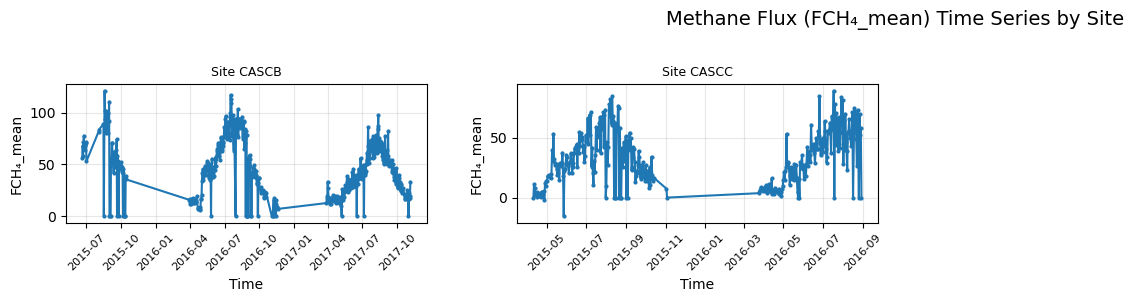

Saved multi-panel figure to: /explore/nobackup/people/spotter5/anna_v/v2/qing/FCH4_timeseries_by_site.png


In [8]:
#!/usr/bin/env python
# coding: utf-8

import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import math

# ------------------ Paths ------------------
CSV_PATH = "/explore/nobackup/people/spotter5/anna_v/v2/qing/flux_data.csv"
OUT_FIG  = "/explore/nobackup/people/spotter5/anna_v/v2/qing/FCH4_timeseries_by_site.png"

# ------------------ Read data ------------------
df = pd.read_csv(CSV_PATH)
print("Columns:", list(df.columns))

# Ensure 'time' exists and is datetime
if "time" not in df.columns:
    raise ValueError("No 'time' column found in flux_data.csv")
df["time"] = pd.to_datetime(df["time"], errors="coerce")

# Drop missing or invalid values
df = df.dropna(subset=["NewID", "FCH4_mean", "time"])
df = df.sort_values(["NewID", "time"])

# ------------------ Unique sites ------------------
sites = sorted(df["NewID"].unique())
n_sites = len(sites)
print(f"Found {n_sites} unique sites with valid data")

# ------------------ Faceted plot ------------------
n_cols = 4
n_rows = math.ceil(n_sites / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3 * n_rows), sharex=False, sharey=False)
axes = axes.flatten()

for i, site in enumerate(sites):
    site_df = df[df["NewID"] == site]
    ax = axes[i]
    ax.plot(site_df["time"], site_df["FCH4_mean"], "-o", markersize=2)
    ax.set_title(f"Site {site}", fontsize=9)
    ax.set_xlabel("Time")
    ax.set_ylabel("FCH₄_mean")
    ax.grid(True, alpha=0.3)

    # Improve x-axis tick spacing & rotation
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_fontsize(8)

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# ------------------ Layout & title ------------------
fig.suptitle("Methane Flux (FCH₄_mean) Time Series by Site", fontsize=14, y=0.99, ha="center")
fig.tight_layout(rect=[0, 0, 1, 0.97])

plt.subplots_adjust(wspace=0.25, hspace=0.4)
# plt.savefig(OUT_FIG, dpi=250)
plt.show()

print(f"Saved multi-panel figure to: {OUT_FIG}")


In [6]:
# ------------------ Paths ------------------
CSV_PATH = "/explore/nobackup/people/spotter5/anna_v/v2/qing/flux_data.csv"
OUT_FIG  = "/explore/nobackup/people/spotter5/anna_v/v2/qing/FCH4_timeseries_by_site.png"

# ------------------ Read data ------------------
df = pd.read_csv(CSV_PATH)

df.columns

Index(['time', 'NewID', 'FCH4_count', 'nbar1', 'nbar2', 'nbar3', 'nbar4',
       'nbar5', 'nbar6', 'nbar7', 'sm_s_wetness', 'sm_r_wetness',
       'sm_p_wetness', 'pa', 'tas', 'spfh', 'ts1', 'ts2', 'ts3', 'rsds',
       'rsdl', 'le', 'h', 'dem', 'slope', 'cti', 'spi', 'FCH4_mean'],
      dtype='object')

In [9]:
file_path = "/explore/nobackup/people/spotter5/anna_v/v2/v2_model_training_final.csv"
df = pd.read_csv(file_path)

df.shape

/explore/nobackup/people/spotter5/temp_dir/ipykernel_4036459/1404087278.py:2: DtypeWarning: Columns (135) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


(60035, 169)